## Imports
Esta célula importa todas as bibliotecas necessárias para o projeto. Inclui `numpy`, `opencv`, `matplotlib`, `seaborn` para manipulação e visualização de dados, além de `sklearn` para pré-processamento e importação dos modelos de Machine Learning (SVM, Random Forest, Regressão Logística).

In [ ]:
!pip install mahotas

import glob
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from skimage.feature import local_binary_pattern
from imblearn.under_sampling import RandomUnderSampler
import mahotas
from sklearn.cluster import KMeans

## Download do Dataset
Esta célula utiliza a biblioteca `kagglehub` para baixar o dataset 'breast-histopathology-images' diretamente para o ambiente de execução.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-histopathology-images' dataset.
Path to dataset files: /kaggle/input/breast-histopathology-images


## Localização das Imagens
Esta célula usa `glob` para encontrar o caminho de todas as imagens PNG dentro da estrutura de diretórios do dataset baixado.

In [ ]:
breast_img = glob.glob(
    path + '/IDC_regular_ps50_idx5/**/*.png',
    recursive=True
)

print("Total de imagens encontradas:", len(breast_img))

Total de imagens encontradas: 277524


## Separação por Classes
Aqui, as imagens são separadas em duas listas (`class_0` e `class_1`) com base no rótulo de classe (0 para IDC Negativo e 1 para IDC Positivo), que está no nome do arquivo.

In [ ]:
class_0 = [img for img in breast_img if img[-5] == '0']
class_1 = [img for img in breast_img if img[-5] == '1']

print("Classe 0 total:", len(class_0))
print("Classe 1 total:", len(class_1))


Classe 0 total: 198738
Classe 1 total: 78786


##Visualização da distribuição das classes.

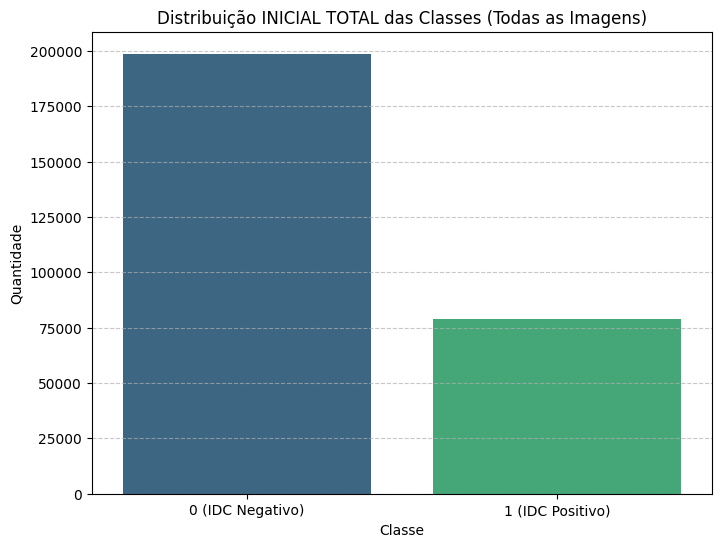

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Criar um DataFrame a partir das contagens de class_0 e class_1
initial_distribution_df = pd.DataFrame({
    'Classe': ['0 (IDC Negativo)', '1 (IDC Positivo)'],
    'Quantidade': [len(class_0), len(class_1)]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Classe', y='Quantidade', data=initial_distribution_df, palette='viridis', hue='Classe', legend=False)
plt.title("Distribuição INICIAL TOTAL das Classes (Todas as Imagens)")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Este gráfico mostra a distribuição total das classes com base em todas as `277524` imagens encontradas, antes de qualquer amostragem ou extração de características.

## Amostra de Imagens
Esta célula seleciona aleatoriamente 10 imagens do dataset e as exibe para visualização, mostrando se são 'IDC Negativo' ou 'IDC Positivo'.

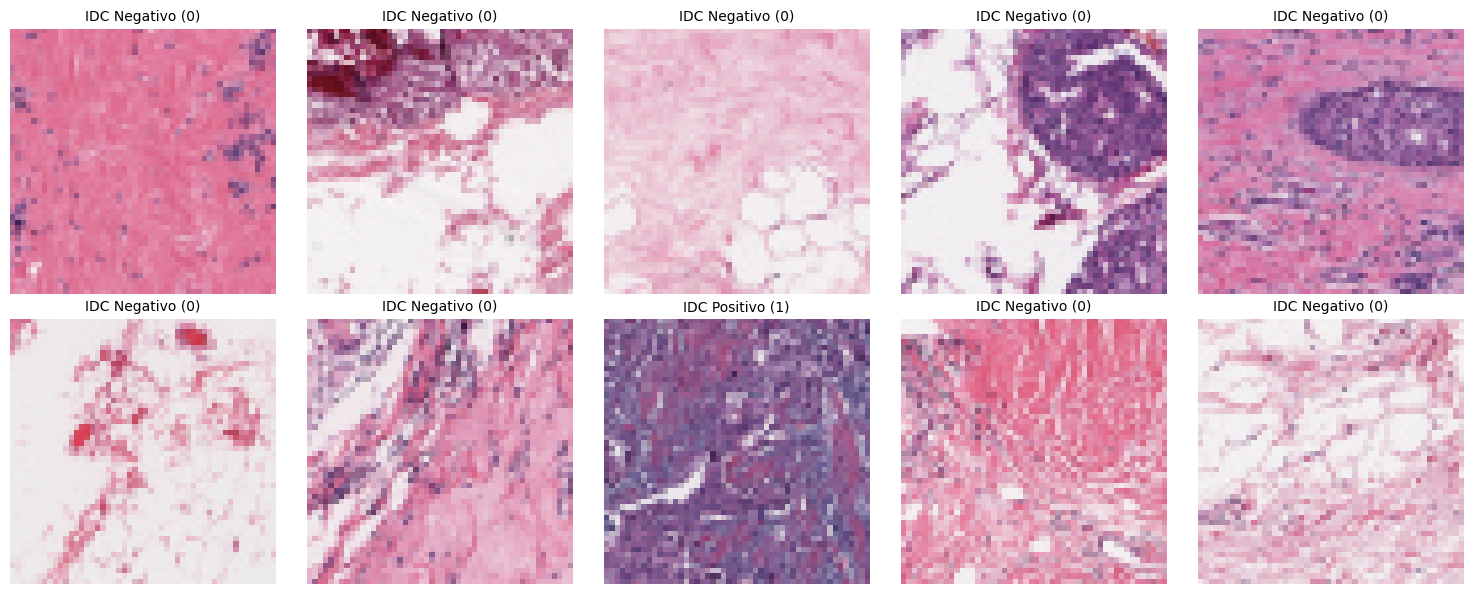

In [ ]:
sample_imgs = random.sample(breast_img, 10)

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(sample_imgs):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    label = "IDC Negativo (0)" if img_path[-5] == '0' else "IDC Positivo (1)"

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Extração de Características (Features)
Esta célula define a função `extrair_features` para calcular diversas características estatísticas e de textura de uma imagem em escala de cinza. Em seguida, aplica essa função a todas as imagens processadas para criar a matriz de features `X` e o vetor de rótulos `y`.

### Atualizações na Extração de Características:
*   **Intensidade e Variação:** Média, desvio padrão, energia de pixels (média quadrática de intensidade) e gradiente médio (Sobel).
*   **Textura e Padrões Locais:** Entropia, histogramas LBP (Local Binary Patterns).
*   **Características GLCM (Gray Level Co-occurrence Matrix):** Contraste, correlação, energia, homogeneidade, dissimilaridade e segundo momento angular (ASM) para capturar a coocorrência de pixels e suas relações espaciais.

In [ ]:
def extrair_features_individual(color_img):
    gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)
    all_features = []

    # 1) PFTAS (Parameter-Free Threshold Adjacency Statistics)
    pftas_features = mahotas.features.pftas(gray_img)
    all_features.extend(pftas_features)

    # 2) Estatísticas dos canais de cor (RGB)
    rgb_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)
    for channel in range(3): # R, G, B
        chan = rgb_img[:, :, channel]
        all_features.append(np.mean(chan))
        all_features.append(np.std(chan))
        all_features.append(skew(chan.flatten()))
        all_features.append(kurtosis(chan.flatten()))

    # 3) Hu Moments
    moments = cv2.moments(gray_img)
    hu_moments = cv2.HuMoments(moments).flatten()
    all_features.extend(hu_moments)

    # 4) Haralick Texture Features
    haralick_features = mahotas.features.haralick(
        gray_img,
        return_mean_ptp=True,
        compute_14th_feature=True,
        distance=2
    )
    all_features.extend(haralick_features.flatten())

    # 5) Histograma de cores (HSV)
    hsv_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv_img], [0], None, [11], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv_img], [1], None, [11], [0, 256]).flatten()
    v_hist = cv2.calcHist([hsv_img], [2], None, [11], [0, 256]).flatten()
    all_features.extend(h_hist)
    all_features.extend(s_hist)
    all_features.extend(v_hist)

    # 6) LBP (Local Binary Pattern)
    radius_lbp = 9
    n_points_lbp = 8 * radius_lbp
    lbp = local_binary_pattern(gray_img, n_points_lbp, radius_lbp, method="uniform")
    (hist_lbp, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points_lbp + 3), range=(0, n_points_lbp + 2))
    hist_lbp = hist_lbp.astype("float")
    hist_lbp /= (hist_lbp.sum() + 1e-7)
    all_features.extend(hist_lbp)

    return np.array(all_features)

# Main feature extraction loop
if 'breast_img' in globals() and 'class_0' in globals() and 'class_1' in globals():
    total_images_to_sample = 40000

    total_class_0_original = len(class_0)
    total_class_1_original = len(class_1)
    total_original = total_class_0_original + total_class_1_original

    prop_class_0 = total_class_0_original / total_original
    prop_class_1 = total_class_1_original / total_original

    target_class_0_count = round(total_images_to_sample * prop_class_0)
    target_class_1_count = round(total_images_to_sample * prop_class_1)

    selected_class_0_paths = random.sample(class_0, min(len(class_0), target_class_0_count))
    selected_class_1_paths = random.sample(class_1, min(len(class_1), target_class_1_count))

    # Prepare a list of tuples for processing
    processed_items = []
    for path in selected_class_0_paths:
        processed_items.append((path, 0))
    for path in selected_class_1_paths:
        processed_items.append((path, 1))
    random.shuffle(processed_items)

    print("Total de imagens selecionadas para extração de features:", len(processed_items))

    # SIFT + Bag of Visual Words preparation
    sift = cv2.SIFT_create()
    descriptors_list_for_kmeans = []
    print("Coletando descritores SIFT para construir o vocabulário visual...")
    for img_path, _ in processed_items:
        img_bgr = cv2.imread(img_path)
        img_bgr_resized = cv2.resize(img_bgr, (50, 50))
        gray_sift = cv2.cvtColor(img_bgr_resized, cv2.COLOR_BGR2GRAY)
        kp, des = sift.detectAndCompute(gray_sift, None)
        if des is not None and des.shape[0] > 0:
            descriptors_list_for_kmeans.append(des)

    kmeans_model = None
    k_clusters = 300
    if descriptors_list_for_kmeans:
        all_sift_descriptors = np.vstack(descriptors_list_for_kmeans)
        if all_sift_descriptors.shape[0] < k_clusters:
            print(f"Aviso: Número de descritores SIFT ({all_sift_descriptors.shape[0]}) é menor que o número de clusters ({k_clusters}). Reduzindo o número de clusters.")
            k_clusters = all_sift_descriptors.shape[0] if all_sift_descriptors.shape[0] > 0 else 1

        if k_clusters > 0:
            kmeans_model = KMeans(n_clusters=k_clusters, random_state=42, n_init='auto', verbose=0)
            print(f"Treinando KMeans para vocabulário BoVW com {k_clusters} clusters...")
            kmeans_model.fit(all_sift_descriptors)
            print("Vocabulário KMeans construído.")
        else:
            print("Não há descritores SIFT suficientes para construir o vocabulário BoVW.")
    else:
        print("Nenhum descritor SIFT encontrado. As features BoVW serão todas zero.")

    X = []
    y = []
    print("Extraindo todas as features combinadas para cada imagem...")
    for img_path, label_val in processed_items:
        img_bgr = cv2.imread(img_path)
        img_bgr_resized = cv2.resize(img_bgr, (50, 50))

        # Extract individual features (PFTAS, Color Stats, Hu Moments, Haralick, HSV Hist, LBP)
        individual_features = extrair_features_individual(img_bgr_resized)

        # Extract SIFT BoVW features
        bovw_features = np.zeros(k_clusters)
        if kmeans_model is not None:
            gray_bovw = cv2.cvtColor(img_bgr_resized, cv2.COLOR_BGR2GRAY)
            kp_bovw, des_bovw = sift.detectAndCompute(gray_bovw, None)
            if des_bovw is not None and len(des_bovw) > 0:
                cluster_assignments = kmeans_model.predict(des_bovw)
                for cluster_id in cluster_assignments:
                    bovw_features[cluster_id] += 1
                if np.sum(bovw_features) > 0:
                    bovw_features = bovw_features / np.sum(bovw_features)

        # Concatenate all features
        all_combined_features = np.concatenate((individual_features, bovw_features))
        X.append(all_combined_features)
        y.append(label_val)

    X = np.array(X)
    y = np.array(y)

    print("Total de imagens processadas:", len(processed_items))
    print("Shape:", X.shape)

elif 'class_0' not in globals() or 'class_1' not in globals():
    print("Error: 'class_0' or 'class_1' not defined. Please ensure image localization and class separation cells are run first.")
    X = np.array([])
    y = np.array([])
else:
    print("Error: 'breast_img' is not defined. Please run the image localization cell (Y71pAXGz-SlD) first.")
    X = np.array([])
    y = np.array([])

Total de imagens selecionadas para extração de features: 40000
Coletando descritores SIFT para construir o vocabulário visual...
Treinando KMeans para vocabulário BoVW com 300 clusters...
Vocabulário KMeans construído.
Extraindo todas as features combinadas para cada imagem...
Total de imagens processadas: 40000
Shape: (40000, 508)


## Divisão Treino-Teste
Esta célula divide os dados (`X` e `y`) em conjuntos de treino e teste (`X_train`, `X_test`, `y_train`, `y_test`) usando `train_test_split`, com 20% dos dados reservados para teste e um `random_state` para reprodutibilidade.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=78, stratify=y
)

## Distribuição das Classes nos Conjuntos Treino e Teste
Esta célula exibe gráficos de contagem para a distribuição das classes (0 e 1) nos conjuntos de treino e teste, garantindo que a divisão foi estratificada e manteve proporções semelhantes.

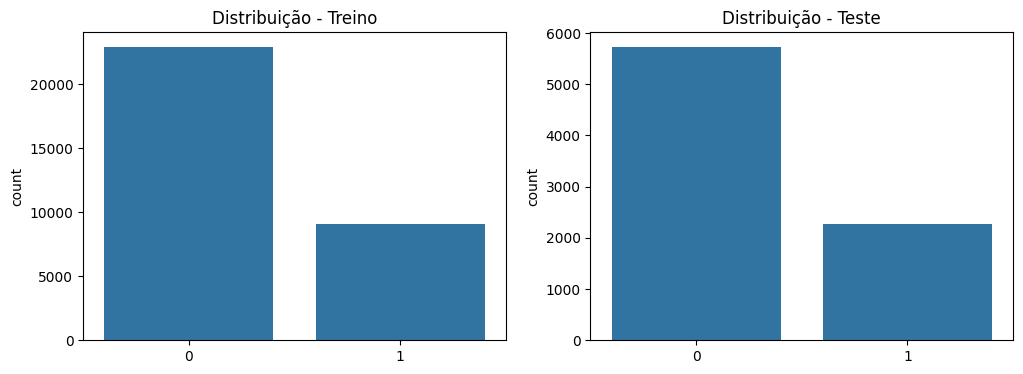

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Distribuição - Treino")

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Distribuição - Teste")

plt.show()

## Função de Avaliação de Modelos
Esta célula define a função `avaliar`, que calcula e imprime métricas de desempenho (acurácia, precisão, recall, F1-score) para um modelo. Além disso, ela gera e exibe uma matriz de confusão, uma Curva ROC (com AUC) e uma Curva Precision-Recall (com Average Precision) para o modelo. A função também sugere um limiar ótimo para priorizar o recall com base em um mínimo de precisão.

In [ ]:
def avaliar(nome, model, X_test, y_test, scores=None, probs=None, threshold=0.5):
    if probs is not None:
        y_pred = (probs >= threshold).astype(int)j
    else:
        if scores is not None:
            y_pred = (scores >= 0).astype(int)
        else:
            y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n--- {nome} ---")
    print(f"Acurácia (Threshold={threshold:.2f}): {acc:.4f}")
    print(f"Precisão (Threshold={threshold:.2f}): {prec:.4f}")
    print(f"Recall (Threshold={threshold:.2f}): {rec:.4f}")
    print(f"F1 Score (Threshold={threshold:.2f}): {f1:.4f}")

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusão - {nome} (Threshold={threshold:.2f})")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

    # ROC Curve Plotting
    if (scores is not None or probs is not None) and len(np.unique(y_test)) > 1:
        decision_values = probs if probs is not None else scores
        fpr, tpr, _ = roc_curve(y_test, decision_values)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{nome} ROC Curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classificador Aleatório')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - {nome}')
        plt.legend()
        plt.grid(True)
        plt.show()

    # Precision-Recall Curve Plotting
    if probs is not None and len(np.unique(y_test)) > 1:
        precision, recall, thresholds_pr = precision_recall_curve(y_test, probs)
        pr_auc = average_precision_score(y_test, probs)
        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, label=f'{nome} PR Curve (AP = {pr_auc:.2f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve - {nome}')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Sugestão para aumentar recall
        min_precision_target = 0.6
        best_threshold = 0.5
        max_recall_at_best_threshold = 0.0

        if len(thresholds_pr) > 0:
            for i in range(len(thresholds_pr)):
                if i < len(precision) and i < len(recall) and precision[i] >= min_precision_target and recall[i] > max_recall_at_best_threshold:
                    max_recall_at_best_threshold = recall[i]
                    best_threshold = thresholds_pr[i]

            if max_recall_at_best_threshold > 0.0:
                print(f"Sugestão de Threshold para Priorizar Recall (Precision >= {min_precision_target:.2f}): {best_threshold:.4f} (Recall resultante: {max_recall_at_best_threshold:.4f})")
            else:
                print(f"Nenhum threshold encontrado para Precision >= {min_precision_target:.2f}. Considere ajustar o min_precision_target.")

## Modelo SVM (LinearSVC)
Esta célula treina um modelo `LinearSVC` (Support Vector Machine com kernel linear) usando um pipeline que inclui `StandardScaler` para normalização. O tempo de treinamento é medido e, em seguida, a função `avaliar` é utilizada para exibir as métricas de desempenho, a matriz de confusão e as curvas ROC/PR para o conjunto de teste.


--- SVM Linear ---
Acurácia (Threshold=0.50): 0.8435
Precisão (Threshold=0.50): 0.6852
Recall (Threshold=0.50): 0.8300
F1 Score (Threshold=0.50): 0.7507


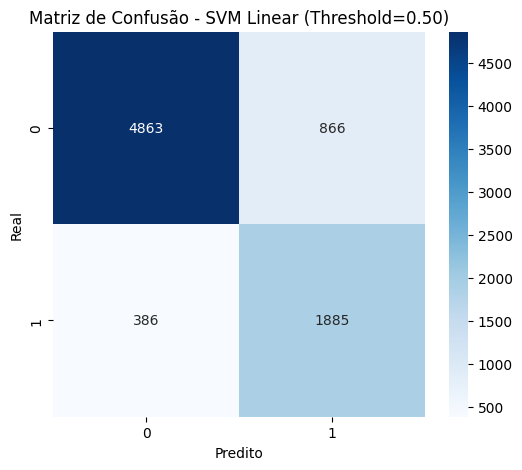

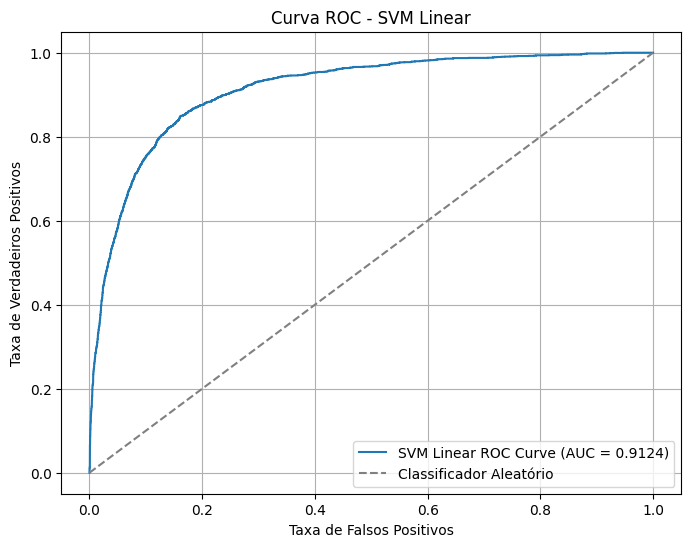

Tempo: 7.88s


In [ ]:
import time
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline

start = time.time()

pipeline_svc = ImbPipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(
        dual=False,
        max_iter=1000,
        C=10,
        tol=1e-2,
        fit_intercept=True,
        class_weight='balanced'
    ))
])

pipeline_svc.fit(X_train, y_train)
svm_time = time.time() - start

svm_scores = pipeline_svc.decision_function(X_test)

avaliar("SVM Linear", pipeline_svc, X_test, y_test, scores=svm_scores, threshold=0.5)

print(f"Tempo: {svm_time:.2f}s")

## Modelo Random Forest Classifier
Esta célula treina um `RandomForestClassifier` usando um pipeline que inclui `StandardScaler` para normalização. O tempo de treinamento é medido, e a função `avaliar` é utilizada para exibir as métricas de desempenho, a matriz de confusão e as curvas ROC/PR para o conjunto de teste, usando as probabilidades preditas pelo modelo.


--- Random Forest ---
Acurácia (Threshold=0.38): 0.8636
Precisão (Threshold=0.38): 0.7316
Recall (Threshold=0.38): 0.8208
F1 Score (Threshold=0.38): 0.7736


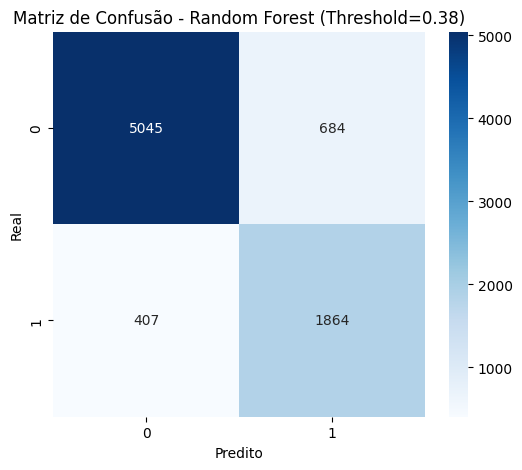

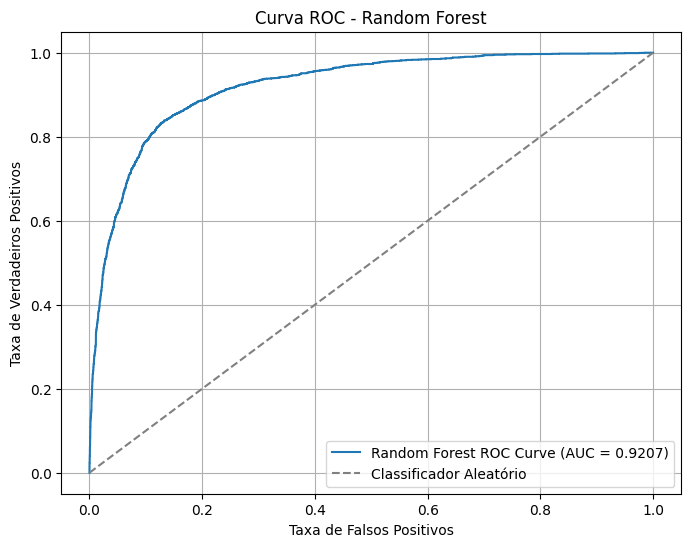

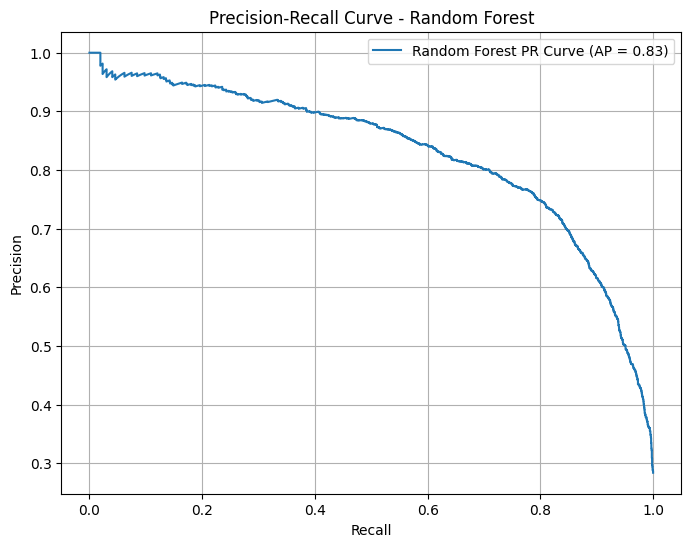

Sugestão de Threshold para Priorizar Recall (Precision >= 0.60): 0.2196 (Recall resultante: 0.9119)
Tempo: 51.53s


In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline

start = time.time()

pipeline_rf = ImbPipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_split=7,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

pipeline_rf.fit(X_train, y_train)
rf_time = time.time() - start

rf_probs = pipeline_rf.predict_proba(X_test)[:, 1]

# Reavaliar com o threshold sugerido para priorizar recall
avaliar("Random Forest", pipeline_rf, X_test, y_test, probs=rf_probs, threshold=0.38)

print(f"Tempo: {rf_time:.2f}s")

## Modelo Regressão Logística
Esta célula treina um modelo de `LogisticRegression` usando um pipeline que inclui `StandardScaler` para normalização. O tempo de treinamento é medido, e a função `avaliar` é utilizada para exibir as métricas de desempenho, a matriz de confusão e as curvas ROC/PR para o conjunto de teste, utilizando as probabilidades preditas pelo modelo.


--- Logistic Regression ---
Acurácia (Threshold=0.55): 0.8531
Precisão (Threshold=0.55): 0.7111
Recall (Threshold=0.55): 0.8129
F1 Score (Threshold=0.55): 0.7586


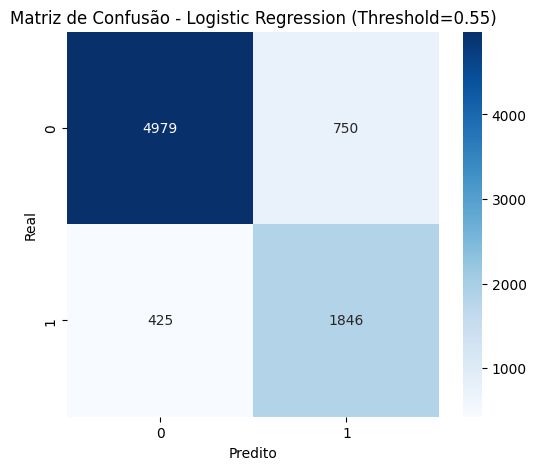

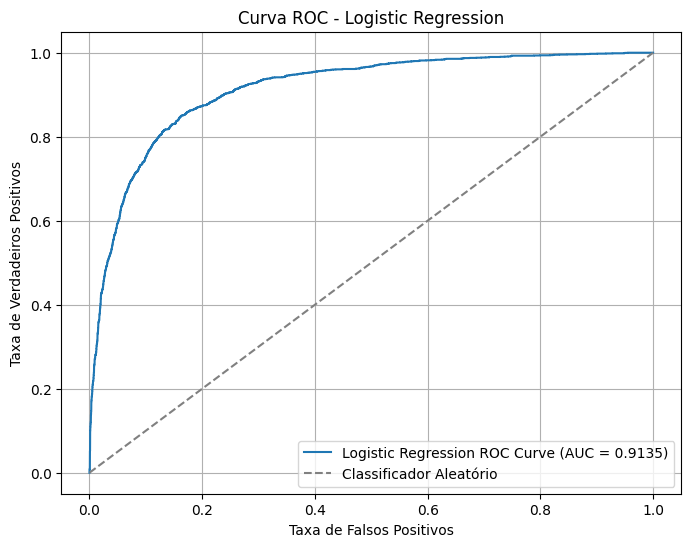

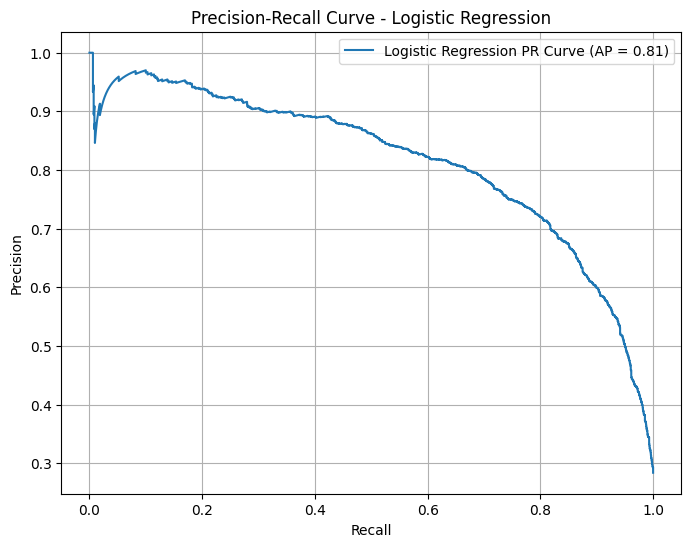

Sugestão de Threshold para Priorizar Recall (Precision >= 0.60): 0.3306 (Recall resultante: 0.8992)
Tempo: 282.92s


In [ ]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline

start = time.time()

pipeline_lr = ImbPipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=1000,
        penalty='l1',
        solver='liblinear',
        random_state=42,
        class_weight='balanced'
    ))
])

pipeline_lr.fit(X_train, y_train)
lr_time = time.time() - start

lr_probs = pipeline_lr.predict_proba(X_test)[:, 1]

avaliar("Logistic Regression", pipeline_lr, X_test, y_test, probs=lr_probs, threshold=0.55)

print(f"Tempo: {lr_time:.2f}s")

## Comparação de Curvas ROC
Esta célula gera um gráfico comparando as Curvas ROC (Receiver Operating Characteristic) de todos os modelos treinados (SVM Linear, Random Forest, Regressão Logística). Isso permite visualizar e comparar o desempenho de cada modelo em termos de sensibilidade e especificidade em diferentes limiares de classificação.

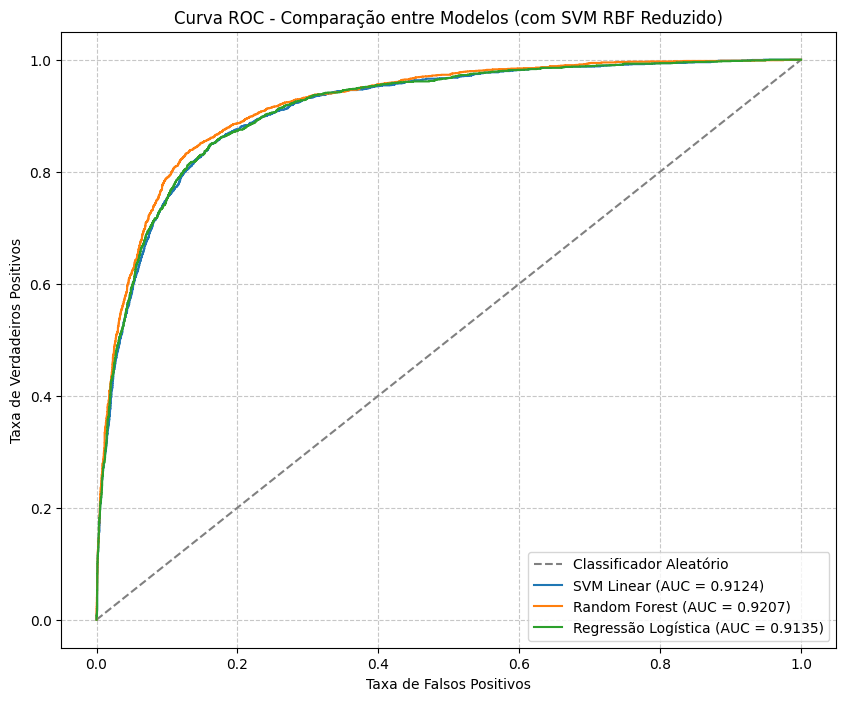

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classificador Aleatório')

if 'svm_scores' in globals():
    fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)
    roc_auc_svm = auc(fpr_svm, tpr_svm)
    plt.plot(fpr_svm, tpr_svm, label=f"SVM Linear (AUC = {roc_auc_svm:.4f})")

if 'rf_probs' in globals():
    fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
    roc_auc_rf = auc(fpr_rf, tpr_rf)
    plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.4f})")

if 'lr_probs' in globals():
    fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
    roc_auc_lr = auc(fpr_lr, tpr_lr)
    plt.plot(fpr_lr, tpr_lr, label=f"Regressão Logística (AUC = {roc_auc_lr:.4f})")

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Comparação entre Modelos (com SVM RBF Reduzido)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
